# Multiple Linear Regression - Toyota Corolla

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler


In [9]:

df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [10]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [11]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

X = df.drop("Price", axis=1)
y = df["Price"]


In [12]:
df.isnull().sum()

Price               0
Age_08_04           0
KM                  0
HP                  0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Weight              0
Fuel_Type_Diesel    0
Fuel_Type_Petrol    0
dtype: int64

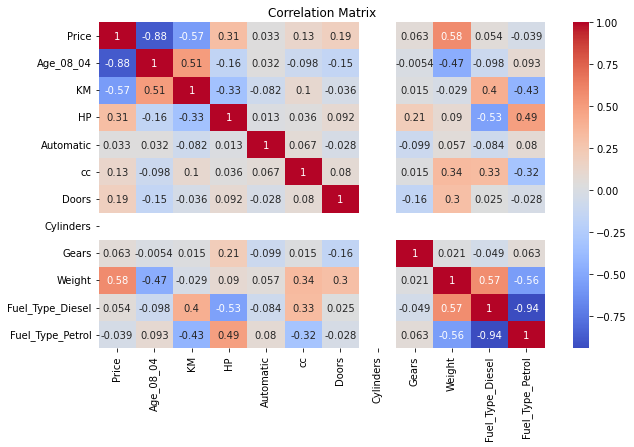

In [16]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

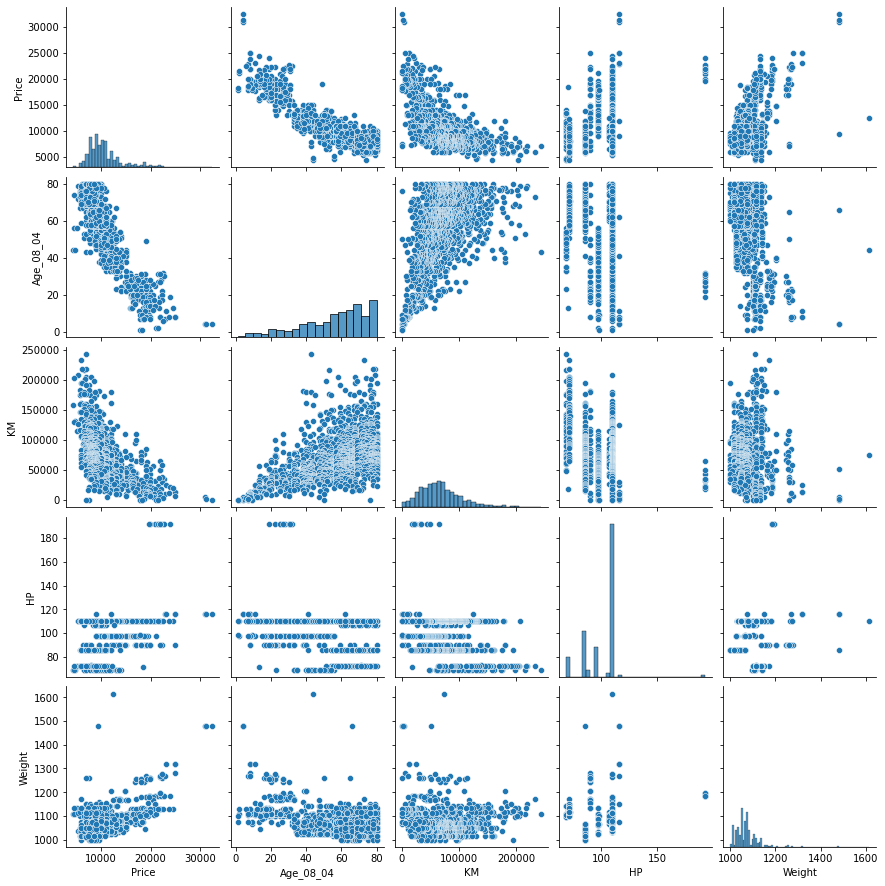

In [20]:
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model = LinearRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print("R2:", r2_score(y_test, y_pred))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


In [22]:
#Model 1

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("R2:", r2_score(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))

R2: 0.8348888040611082
RMSE: 1484.2654153296514


In [23]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})
coef_df

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,9.663381e-13
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [24]:
#Model 2
features = ['Age_08_04','KM','HP','Weight']

X2 = df[features]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("R2:", r2_score(y_test2, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))


R2: 0.8506068681500583
RMSE: 1411.85020911323


In [25]:
#Model 3

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("R2:", r2_score(y_test3, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test3, y_pred3)))

R2: 0.8348888040611081
RMSE: 1484.265415329652


In [26]:
#Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train3, y_train3)

y_pred_ridge = ridge.predict(X_test3)

print("R2:", r2_score(y_test3, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test3, y_pred_ridge)))

R2: 0.835065814541473
RMSE: 1483.4695850205603


In [28]:
#Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train3, y_train3)

y_pred_lasso = lasso.predict(X_test3)

print("R2:", r2_score(y_test3, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test3, y_pred_lasso)))

R2: 0.8349119754675461
RMSE: 1484.1612621141915


### 1.What is Normalization & Standardization and how is it helpful?

Normalization and Standardization are techniques used to scale data.
Normalization converts values into a fixed range, usually between 0 and 1.
Standardization transforms data so that it has mean 0 and standard deviation 1.
Normalization is useful when data has large differences in scale.
Standardization is preferred for machine learning models like linear regression.
These techniques help improve model performance and training stability.
They also ensure that no single feature dominates due to its large values.

### 2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables are highly correlated with each other.
It can make model coefficients unstable and hard to interpret.
One way to handle it is by removing highly correlated features.
Another method is using Ridge Regression, which reduces coefficient values.
Lasso Regression can also help by eliminating less important features.
We can also use VIF (Variance Inflation Factor) to detect multicollinearity.
Reducing multicollinearity improves model accuracy and reliability.